# Clinical 3T MRI — B-field Mapping (All Coordinates)

Pipeline: Load → Clean outliers → Crop static ends → Split doubles → Map time→position → B vs z → dB/dz → B·dB/dz → Summary table

**G6 is the representative coordinate** shown inline; all coordinates saved to `betterPlots/`.


## 1 · Imports & configuration

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.optimize import curve_fit

# ── Config ────────────────────────────────────────────────────────────────────
DATA_FOLDER    = Path('DataCollectionFolderMRIProject')
PLOTS_DIR      = 'betterPlots'           # assumed to already exist
TOTAL_DIST_MM  = 1252.0                  # full rail travel in mm
GAUSS_TO_TESLA = 1e-4
MM_TO_M        = 1e-3
GRADIENT_CONV  = GAUSS_TO_TESLA / MM_TO_M   # G/mm → T/m
PRODUCT_CONV   = GAUSS_TO_TESLA * GRADIENT_CONV  # G²/mm → T²/m

# All coordinate prefixes and their N-runs
PREFIXES = ['00', 'A3', 'A6', 'D3', 'G3', 'G6']
# '00' has N1-N4, all others have N1 and N2
ALL_KEYS = (
    [f'00N{i}' for i in range(1, 5)] +
    [f'{p}N{n}' for p in PREFIXES[1:] for n in [1, 2]]
)
# N1/N3 = forward (entering bore), N2/N4 = backward (exiting bore)
def is_backward(key): return 'N2' in key.upper() or 'N4' in key.upper()

# Instrument error model: ±1% of |B| + 1 G
def gauss_error(flux): return 0.01 * np.abs(flux) + 1.0

print("Config ready.")
print(f"Coordinates: {PREFIXES}")
print(f"All run keys: {ALL_KEYS}")


Config ready.
Coordinates: ['00', 'A3', 'A6', 'D3', 'G3', 'G6']
All run keys: ['00N1', '00N2', '00N3', '00N4', 'A3N1', 'A3N2', 'A6N1', 'A6N2', 'D3N1', 'D3N2', 'G3N1', 'G3N2', 'G6N1', 'G6N2']


## 2 · Load all CSV files

In [2]:
raw = {}
missing = []

for key in ALL_KEYS:
    # file naming: MRI3Tesla_G6N1.csv
    prefix = key[:-2]   # e.g. 'G6'
    fpath  = DATA_FOLDER / f'MRI3Tesla_{key}.csv'
    if not fpath.exists():
        missing.append(key)
        continue
    df = pd.read_csv(fpath)[['time', 'flux']]
    raw[key] = df

print(f"Loaded {len(raw)} files.")
if missing:
    print(f"Missing (skipped): {missing}")

# Quick sanity: show time range for each
for key, df in sorted(raw.items()):
    print(f"  {key}: {len(df):>4} rows   t = {df['time'].iloc[0]:.2f} → {df['time'].iloc[-1]:.2f} s")


Loaded 14 files.
  00N1:  120 rows   t = 0.25 → 30.00 s
  00N2:  120 rows   t = 0.25 → 30.00 s
  00N3:  120 rows   t = 0.25 → 30.00 s
  00N4:  120 rows   t = 0.25 → 30.00 s
  A3N1:  120 rows   t = 0.25 → 30.00 s
  A3N2:  120 rows   t = 0.25 → 30.00 s
  A6N1:  120 rows   t = 0.25 → 30.00 s
  A6N2:  120 rows   t = 0.25 → 30.00 s
  D3N1:  120 rows   t = 0.25 → 30.00 s
  D3N2:  120 rows   t = 0.25 → 30.00 s
  G3N1:  120 rows   t = 0.25 → 30.00 s
  G3N2:  120 rows   t = 0.25 → 30.00 s
  G6N1:  120 rows   t = 0.25 → 30.00 s
  G6N2:  120 rows   t = 0.25 → 30.00 s


## 3 · B vs Time — G6 only (representative)

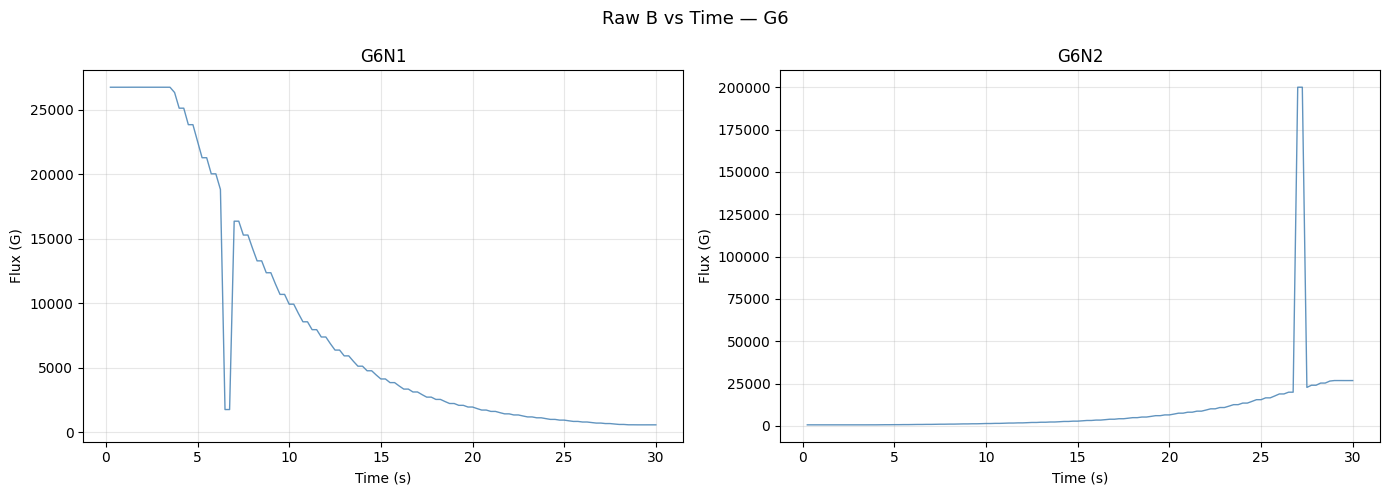

Saved G6_BvsTime_raw.png


In [3]:
g6_keys = [k for k in raw if k.startswith('G6')]

fig, axes = plt.subplots(1, len(g6_keys), figsize=(7*len(g6_keys), 5))
if len(g6_keys) == 1: axes = [axes]

for ax, key in zip(axes, g6_keys):
    df = raw[key]
    ax.plot(df['time'], df['flux'], color='steelblue', lw=1, alpha=0.85)
    ax.set_title(key)
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Flux (G)')
    ax.grid(True, alpha=0.3)

fig.suptitle('Raw B vs Time — G6', fontsize=13)
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/G6_BvsTime_raw.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved G6_BvsTime_raw.png")


## 4 · Remove gaussmeter artefacts (exponential 3-σ cut)

In [4]:
def remove_outliers(df, sigma_cut=3.0):
    """Fit exponential baseline; remove residuals > sigma_cut * std."""
    def exp_func(t, a, b, c): return a * np.exp(-b * t) + c
    df = df.copy().reset_index(drop=True)
    try:
        p0 = [df['flux'].max(), 0.1, df['flux'].min()]
        popt, _ = curve_fit(exp_func, df['time'], df['flux'], p0=p0, maxfev=10000)
        residuals = df['flux'] - exp_func(df['time'], *popt)
        mask = np.abs(residuals) < sigma_cut * residuals.std()
        removed = (~mask).sum()
        if removed:
            print(f"    removed {removed} outlier(s) ({100*removed/len(df):.1f}%)")
        return df[mask].reset_index(drop=True)
    except Exception as e:
        print(f"    fit failed ({e}) — keeping all")
        return df

clean = {}
for key, df in sorted(raw.items()):
    clean[key] = remove_outliers(df)
print("Outlier removal done.")


    removed 1 outlier(s) (0.8%)
    removed 1 outlier(s) (0.8%)
    removed 2 outlier(s) (1.7%)
    removed 2 outlier(s) (1.7%)
    removed 2 outlier(s) (1.7%)
    removed 2 outlier(s) (1.7%)
    removed 2 outlier(s) (1.7%)
    removed 2 outlier(s) (1.7%)
    removed 2 outlier(s) (1.7%)
    removed 1 outlier(s) (0.8%)
    removed 1 outlier(s) (0.8%)
    removed 2 outlier(s) (1.7%)
    removed 2 outlier(s) (1.7%)
    removed 2 outlier(s) (1.7%)
Outlier removal done.


## 5 · Crop static ends (probe not moving)

In [5]:
def crop_static_ends(df, tolerance=1.0):
    """Remove leading/trailing near-constant flux plateaus."""
    flux = df['flux'].values
    n    = len(flux)
    start = 0
    while start < n-1 and abs(flux[start] - flux[start+1]) <= tolerance:
        start += 1
    end = n-1
    while end > 0 and abs(flux[end] - flux[end-1]) <= tolerance:
        end -= 1
    if start > end:
        start, end = 0, n-1
    return df.iloc[start:end+1].reset_index(drop=True)

cropped = {}
for key, df in sorted(clean.items()):
    c = crop_static_ends(df, tolerance=1.0)
    cropped[key] = c

print("Cropping done.")
for key, df in sorted(cropped.items()):
    print(f"  {key}: {len(df):>4} rows  t = {df['time'].iloc[0]:.2f} → {df['time'].iloc[-1]:.2f} s")


Cropping done.
  00N1:  102 rows  t = 2.50 → 28.00 s
  00N2:  110 rows  t = 1.75 → 29.25 s
  00N3:   84 rows  t = 3.00 → 24.25 s
  00N4:  102 rows  t = 3.00 → 28.75 s
  A3N1:  101 rows  t = 3.50 → 29.00 s
  A3N2:  105 rows  t = 3.50 → 30.00 s
  A6N1:  111 rows  t = 0.50 → 28.25 s
  A6N2:  103 rows  t = 3.50 → 29.50 s
  D3N1:  105 rows  t = 2.25 → 28.75 s
  D3N2:  106 rows  t = 3.00 → 29.50 s
  G3N1:  100 rows  t = 3.25 → 28.25 s
  G3N2:  103 rows  t = 4.00 → 30.00 s
  G6N1:  101 rows  t = 3.50 → 29.00 s
  G6N2:  103 rows  t = 3.50 → 29.50 s


## 6 · Split duplicate samples into sub-runs A and B

The gaussmeter samples at 0.25 s but the probe moves at ~0.5 s cadence, so most
spatial positions are measured **twice** (identical flux values back-to-back).
We group consecutive identical readings and take:
- **Sub-run A** = first reading of each group
- **Sub-run B** = second reading of each group (skipped for singletons)

This gives two independent spatial sweeps per direction.


In [6]:
def split_doubles(df, tol=1.0):
    """
    Group consecutive rows with |Δflux| <= tol.
    Return (subA, subB) DataFrames sorted by time.
    subB will be shorter if some groups have only 1 reading.
    """
    flux = df['flux'].values
    groups = []
    i = 0
    while i < len(flux):
        j = i + 1
        while j < len(flux) and abs(flux[j] - flux[i]) <= tol:
            j += 1
        groups.append(list(range(i, j)))
        i = j

    idx_A = [g[0] for g in groups]
    idx_B = [g[1] for g in groups if len(g) >= 2]

    return df.iloc[idx_A].reset_index(drop=True), df.iloc[idx_B].reset_index(drop=True)

split = {}   # key → {'A': df, 'B': df}
for key, df in sorted(cropped.items()):
    A, B = split_doubles(df)
    split[key] = {'A': A, 'B': B}

print("Splitting done.")
for key, subs in sorted(split.items()):
    print(f"  {key}:  A={len(subs['A'])} pts   B={len(subs['B'])} pts")


Splitting done.
  00N1:  A=61 pts   B=41 pts
  00N2:  A=61 pts   B=41 pts
  00N3:  A=51 pts   B=33 pts
  00N4:  A=58 pts   B=36 pts
  A3N1:  A=61 pts   B=40 pts
  A3N2:  A=62 pts   B=41 pts
  A6N1:  A=64 pts   B=44 pts
  A6N2:  A=62 pts   B=41 pts
  D3N1:  A=63 pts   B=42 pts
  D3N2:  A=63 pts   B=43 pts
  G3N1:  A=60 pts   B=40 pts
  G3N2:  A=62 pts   B=41 pts
  G6N1:  A=61 pts   B=40 pts
  G6N2:  A=62 pts   B=41 pts


## 7 · Map time → position (constant average velocity)

In [7]:
def map_position(df, key, total_dist=TOTAL_DIST_MM):
    """Linear time→position mapping; reverse direction for N2/N4 runs."""
    df = df.copy()
    t0, t1 = df['time'].iloc[0], df['time'].iloc[-1]
    dt = t1 - t0
    if dt <= 0:
        df['position'] = np.nan
        return df
    v = total_dist / dt
    df['position'] = (df['time'] - t0) * v
    if is_backward(key):
        df['position'] = total_dist - df['position']
    return df

mapped = {}   # key → {'A': df, 'B': df}
for key, subs in sorted(split.items()):
    mapped[key] = {
        sub: map_position(df, key)
        for sub, df in subs.items()
    }

print("Mapping done.")


Mapping done.


## 8 · Central-difference gradient helper

In [8]:
def central_diff(pos_mm, flux_G, bin_size_mm=12.0):
    """
    Bin flux into bin_size_mm bins then apply 2nd-order central differences.
    Returns (z_binned, dBdz_G_per_mm, B_binned).
    """
    pos  = np.asarray(pos_mm,  dtype=float)
    flux = np.asarray(flux_G,  dtype=float)

    # sort by position first
    order = np.argsort(pos)
    pos, flux = pos[order], flux[order]

    bins = np.arange(np.floor(pos.min()), np.ceil(pos.max()) + bin_size_mm, bin_size_mm)
    idx  = np.digitize(pos, bins)
    z_b, B_b = [], []
    for i in range(1, len(bins)):
        m = idx == i
        if m.sum() > 0:
            z_b.append(pos[m].mean())
            B_b.append(flux[m].mean())

    z_b  = np.array(z_b)
    B_b  = np.array(B_b)
    n    = len(z_b)
    dBdz = np.full(n, np.nan)

    dz_c = z_b[2:] - z_b[:-2]
    dz_c[dz_c == 0] = np.nan
    dBdz[1:-1] = (B_b[2:] - B_b[:-2]) / dz_c

    dz_l = z_b[1]  - z_b[0]
    dz_r = z_b[-1] - z_b[-2]
    if dz_l != 0: dBdz[0]  = (B_b[1]  - B_b[0])  / dz_l
    if dz_r != 0: dBdz[-1] = (B_b[-1] - B_b[-2]) / dz_r

    # clip top 2% outliers
    finite = dBdz[np.isfinite(dBdz)]
    if len(finite):
        hi = np.percentile(np.abs(finite), 98)
        dBdz[np.abs(dBdz) > hi] = np.nan

    return z_b, dBdz, B_b

print("central_diff() ready.")


central_diff() ready.


## 9 · Plot helper (runs all coordinates, saves to betterPlots/)

In [9]:
SUB_COLORS  = {'A': 'steelblue',   'B': 'darkorange'}
SUB_LABELS  = {'A': 'Sub-run A',   'B': 'Sub-run B'}
PASS_TITLES = {'fwd': 'Forward (entering bore)', 'bwd': 'Backward (exiting bore)'}

def get_pass_keys(prefix):
    """Return (forward_keys, backward_keys) for a given coordinate prefix."""
    all_k = [k for k in mapped if k.startswith(prefix)]
    fwd   = [k for k in all_k if not is_backward(k)]
    bwd   = [k for k in all_k if     is_backward(k)]
    return fwd, bwd

def plot_coordinate(prefix, show=False):
    """
    For one coordinate, produce three figures (B, dB/dz, B·dB/dz),
    each with Forward | Backward subplots, all sub-runs overlaid.
    Saves PNGs; shows only if show=True.
    """
    fwd_keys, bwd_keys = get_pass_keys(prefix)
    pass_map = {'fwd': fwd_keys, 'bwd': bwd_keys}

    # ── B vs position ────────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for ax, (pass_label, keys) in zip(axes, pass_map.items()):
        for key in keys:
            for sub, df in mapped[key].items():
                ok = df['position'].notna() & df['flux'].notna()
                ax.plot(df.loc[ok,'position'], df.loc[ok,'flux'],
                        color=SUB_COLORS[sub], lw=1.2, alpha=0.75,
                        label=f'{key} {SUB_LABELS[sub]}')
        ax.set_xlabel('Position (mm)')
        ax.set_ylabel('B (G)')
        ax.set_title(PASS_TITLES[pass_label])
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=8)
    fig.suptitle(f'{prefix} — B vs Position', fontsize=13)
    plt.tight_layout()
    plt.savefig(f'{PLOTS_DIR}/{prefix}_BvsPosition.png', dpi=300, bbox_inches='tight')
    if show: plt.show()
    else:    plt.close()

    # ── dB/dz vs position ────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for ax, (pass_label, keys) in zip(axes, pass_map.items()):
        for key in keys:
            for sub, df in mapped[key].items():
                ok = df['position'].notna() & df['flux'].notna()
                if ok.sum() < 3: continue
                z_b, dBdz, _ = central_diff(df.loc[ok,'position'].values,
                                             df.loc[ok,'flux'].values)
                v = np.isfinite(dBdz)
                ax.plot(z_b[v], dBdz[v],
                        color=SUB_COLORS[sub], lw=1.4, alpha=0.75,
                        label=f'{key} {SUB_LABELS[sub]}')
        ax.axhline(0, color='k', lw=0.8, ls='--', alpha=0.4)
        ax.set_xlabel('Position (mm)')
        ax.set_ylabel('dB/dz  (G/mm)')
        ax.set_title(PASS_TITLES[pass_label])
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=8)
    fig.suptitle(f'{prefix} — dB/dz vs Position', fontsize=13)
    plt.tight_layout()
    plt.savefig(f'{PLOTS_DIR}/{prefix}_gradB.png', dpi=300, bbox_inches='tight')
    if show: plt.show()
    else:    plt.close()

    # ── B·dB/dz vs position ──────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for ax, (pass_label, keys) in zip(axes, pass_map.items()):
        for key in keys:
            for sub, df in mapped[key].items():
                ok = df['position'].notna() & df['flux'].notna()
                if ok.sum() < 3: continue
                z_b, dBdz, B_b = central_diff(df.loc[ok,'position'].values,
                                               df.loc[ok,'flux'].values)
                BgradB = B_b * dBdz
                v = np.isfinite(BgradB)
                ax.plot(z_b[v], BgradB[v],
                        color=SUB_COLORS[sub], lw=1.4, alpha=0.75,
                        label=f'{key} {SUB_LABELS[sub]}')
        ax.axhline(0, color='k', lw=0.8, ls='--', alpha=0.4)
        ax.set_xlabel('Position (mm)')
        ax.set_ylabel('B·dB/dz  (G²/mm)')
        ax.set_title(PASS_TITLES[pass_label])
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=8)
    fig.suptitle(f'{prefix} — B·dB/dz vs Position', fontsize=13)
    plt.tight_layout()
    plt.savefig(f'{PLOTS_DIR}/{prefix}_BgradB.png', dpi=300, bbox_inches='tight')
    if show: plt.show()
    else:    plt.close()

print("plot_coordinate() ready.")


plot_coordinate() ready.


## 10 · Generate all plots (G6 shown inline, rest saved silently)

  00: saved B, dB/dz, B·dB/dz plots 
  A3: saved B, dB/dz, B·dB/dz plots 
  A6: saved B, dB/dz, B·dB/dz plots 
  D3: saved B, dB/dz, B·dB/dz plots 
  G3: saved B, dB/dz, B·dB/dz plots 


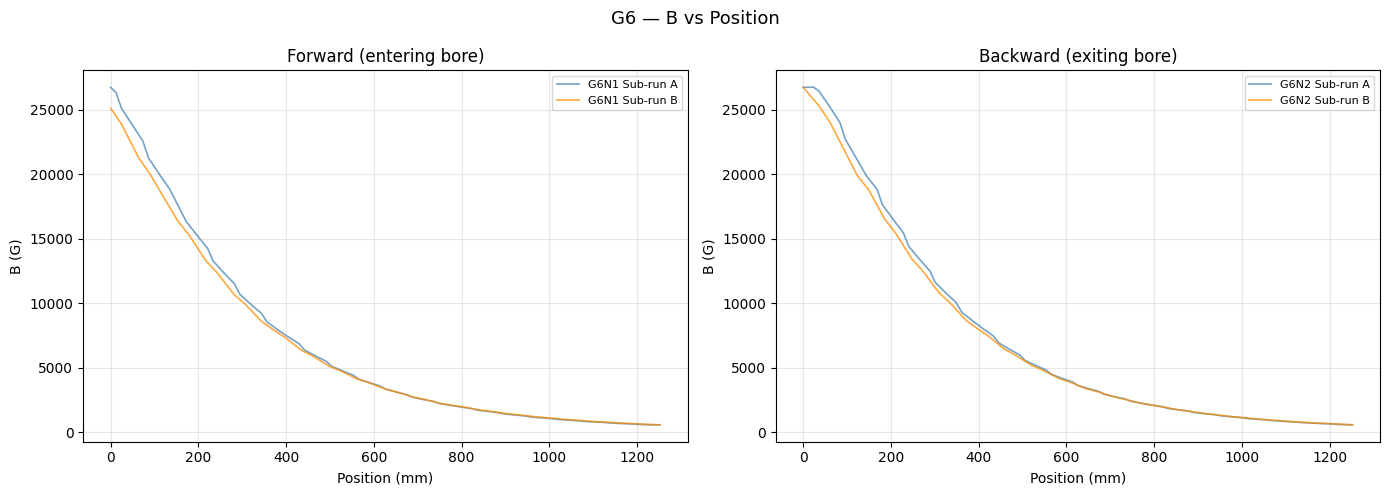

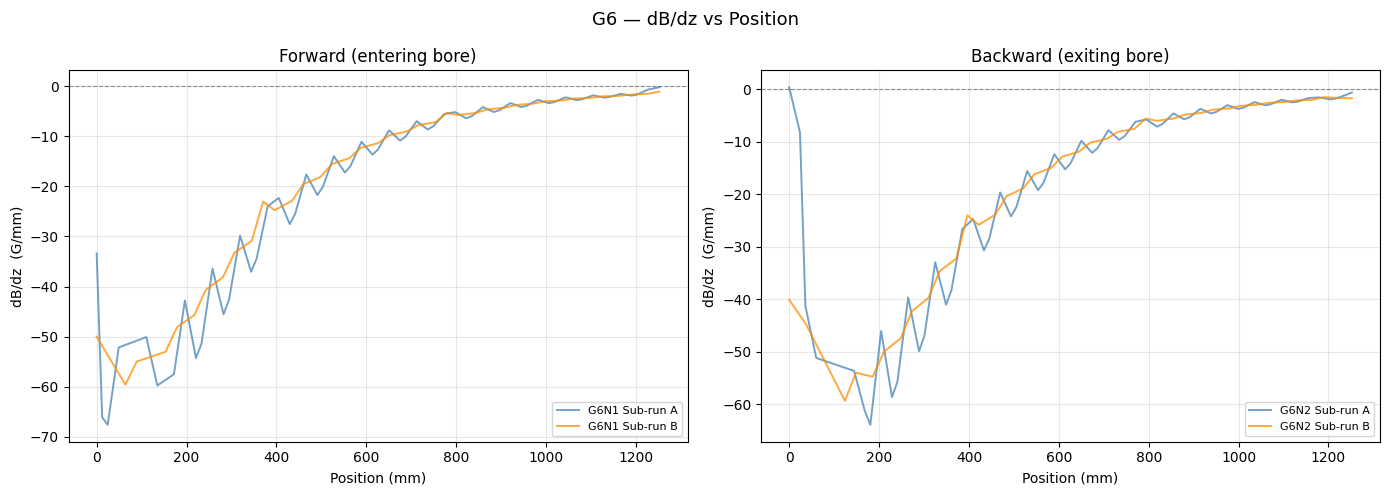

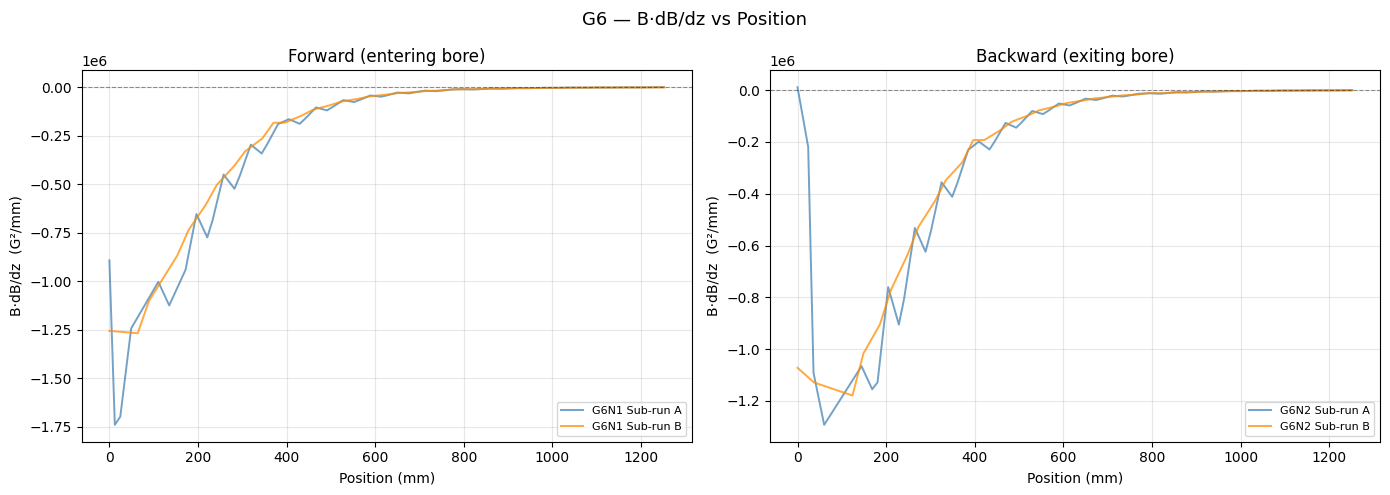

  G6: saved B, dB/dz, B·dB/dz plots (shown inline)


In [10]:
for prefix in PREFIXES:
    keys_present = [k for k in mapped if k.startswith(prefix)]
    if not keys_present:
        print(f"  {prefix}: no data found, skipping")
        continue
    show_inline = (prefix == 'G6')
    plot_coordinate(prefix, show=show_inline)
    print(f"  {prefix}: saved B, dB/dz, B·dB/dz plots {'(shown inline)' if show_inline else ''}")


## 11 · Summary — max |B·dB/dz| per coordinate in SI units

In [11]:

summary_rows = []

for prefix in PREFIXES:
    fwd_keys, bwd_keys = get_pass_keys(prefix)

    for pass_name, keys in [('Forward', fwd_keys), ('Backward', bwd_keys)]:
        for key in keys:
            for sub, df in sorted(mapped[key].items()):
                ok = df['position'].notna() & df['flux'].notna()
                if ok.sum() < 3:
                    continue

                pos  = df.loc[ok, 'position'].values
                flux = df.loc[ok, 'flux'].values

                # ── Max |B| ────────────────────────────────────────────────
                idx_maxB  = np.argmax(np.abs(flux))
                max_B     = flux[idx_maxB]
                pos_maxB  = pos[idx_maxB]

                # ── Gradient ───────────────────────────────────────────────
                z_b, dBdz, B_b = central_diff(pos, flux)
                ok_g = np.isfinite(dBdz)
                if ok_g.sum() == 0:
                    continue
                idx_maxG  = np.nanargmax(np.abs(dBdz[ok_g]))
                max_grad  = dBdz[ok_g][idx_maxG]
                pos_maxG  = z_b[ok_g][idx_maxG]

                # ── B·dB/dz ────────────────────────────────────────────────
                BgradB    = B_b * dBdz
                ok_bg     = np.isfinite(BgradB)
                idx_maxBg = np.nanargmax(np.abs(BgradB[ok_bg]))
                max_BgradB = BgradB[ok_bg][idx_maxBg]
                pos_maxBg  = z_b[ok_bg][idx_maxBg]

                # ── General behaviour ──────────────────────────────────────
                B_range = flux.max() - flux.min()
                trend   = 'rises' if flux[-1] > flux[0] else 'falls'
                behaviour = (f"B {trend} by {B_range:.0f} G over "
                             f"{pos.min():.0f}–{pos.max():.0f} mm")

                summary_rows.append({
                    'coord':      prefix,
                    'pass':       pass_name,
                    'sub_run':    sub,
                    'max_B_T':    max_B    * GAUSS_TO_TESLA,
                    'pos_maxB_mm': pos_maxB,
                    'max_gradB_Tm': max_grad * GRADIENT_CONV,
                    'pos_maxG_mm':  pos_maxG,
                    'max_BgradB_T2m': max_BgradB * PRODUCT_CONV,
                    'pos_maxBg_mm':   pos_maxBg,
                    'behaviour':  behaviour,
                })

# ── Print table ───────────────────────────────────────────────────────────────
hdr = (f"{'Coord':>6} {'Pass':>9} {'Sub':>4}  "
       f"{'max|B|(T)':>10} {'@(mm)':>7}  "
       f"{'max|dB/dz|(T/m)':>16} {'@(mm)':>7}  "
       f"{'max|B·∇B|(T²/m)':>16} {'@(mm)':>7}")
print(hdr)
print('-' * len(hdr))
for r in summary_rows:
    print(f"{r['coord']:>6} {r['pass']:>9} {r['sub_run']:>4}  "
          f"{abs(r['max_B_T']):>10.4f} {r['pos_maxB_mm']:>7.1f}  "
          f"{abs(r['max_gradB_Tm']):>16.4f} {r['pos_maxG_mm']:>7.1f}  "
          f"{abs(r['max_BgradB_T2m']):>16.5f} {r['pos_maxBg_mm']:>7.1f}")
print()

# ── General behaviour ─────────────────────────────────────────────────────────
print("General behaviour:")
seen = set()
for r in summary_rows:
    key = (r['coord'], r['pass'], r['sub_run'])
    if key not in seen:
        seen.add(key)
        print(f"  {r['coord']:>6} {r['pass']:>9} sub-{r['sub_run']}:  {r['behaviour']}")

# ── Note on sub-run A sawtooth ────────────────────────────────────────────────
print()
print("Note: Sub-run A may show sawtooth-like gradients due to irregular position")
print("spacing caused by singletons (positions sampled only once) interspersed")
print("among paired readings. Sub-run B has more uniform spacing and cleaner")
print("gradient profiles. Left for further consideration.")

summary_df = pd.DataFrame(summary_rows)
summary_df


 Coord      Pass  Sub   max|B|(T)   @(mm)   max|dB/dz|(T/m)   @(mm)   max|B·∇B|(T²/m)   @(mm)
---------------------------------------------------------------------------------------------
    00   Forward    A      2.6823     0.0            6.5909    24.5          16.85424    24.5
    00   Forward    B      2.5572     0.0            6.0788    89.4          13.28090     0.0
    00   Forward    A      2.6843     0.0           14.7709    29.5          31.15626    29.5
    00   Forward    B      2.1093     0.0            4.6392    30.9           9.19211    30.9
    00  Backward    A      2.6851    24.8            6.4808   136.4          13.99200   136.4
    00  Backward    B      2.6851    25.0            6.2435   175.3          14.59967    87.6
    00  Backward    A      2.6853    89.4            6.9143   153.3          16.98240   140.5
    00  Backward    B      2.6845    77.4            6.0462   142.0          15.24738   142.0
    A3   Forward    A      2.7815     0.0            7.9053 

,coord,pass,sub_run,max_B_T,pos_maxB_mm,max_gradB_Tm,pos_maxG_mm,max_BgradB_T2m,pos_maxBg_mm,behaviour
0,00,Forward,A,2.6823,0.000000,-6.590895,24.549020,-16.854236,24.549020,B falls by 26254 G over 0–1252 mm
1,00,Forward,B,2.5572,0.000000,-6.078818,89.428571,-13.280896,0.000000,B falls by 24994 G over 0–1252 mm
2,00,Forward,A,2.6843,0.000000,-14.770900,29.458824,-31.156259,29.458824,B falls by 26274 G over 0–1252 mm
3,00,Forward,B,2.1093,0.000000,-4.639200,30.913580,-9.192111,30.913580,B falls by 20521 G over 0–1252 mm
4,00,Backward,A,2.6851,24.792079,-6.480780,136.356436,-13.992003,136.356436,B rises by 26281 G over 0–1252 mm
5,00,Backward,B,2.6851,25.040000,-6.243450,175.280000,-14.599673,87.640000,B rises by 26272 G over 0–1252 mm
6,00,Backward,A,2.6853,89.428571,-6.914271,153.306122,-16.982403,140.530612,B rises by 26283 G over 0–1252 mm
7,00,Backward,B,2.6845,77.443299,-6.046230,141.979381,-15.247383,141.979381,B rises by 26270 G over 0–1252 mm
8,A3,Forward,A,2.7815,0.000000,-7.905272,24.549020,-20.798769,24.549020,B falls by 27278 G over 0–1252 mm
9,A3,Forward,B,2.6310,0.000000,-7.232588,63.877551,-16.300222,0.000000,B falls by 25766 G over 0–1252 mm
